In [1]:
from google.colab import files
files.upload()

Saving glass.xlsx to glass.xlsx


{'glass.xlsx': b'PK\x03\x04\x14\x00\x08\x08\x08\x00U-tX\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x18\x00\x00\x00xl/drawings/drawing1.xml\x9d\xd0]n\xc20\x0c\x07\xf0\x13\xec\x0eU\xdeiZ\x18\x13C\x14^\xd0N0\x0e\xe0%n\x1b\x91\x8f\xca\x0e\xa3\xdc~\xd1J6i{\x01\x1em\xcb?\xf9\xef\xcdnt\xb6\xf8Db\x13|#\xea\xb2\x12\x05z\x15\xb4\xf1]#\x0e\xefo\xb3\x95(8\x82\xd7`\x83\xc7F\\\x90\xc5n\xfb\xb4\x195\xad\xcf\xbc\xa7"\xed{^\xa7\xb2\x11}\x8c\xc3ZJV=:\xe02\x0c\xe8\xd3\xb4\r\xe4 \xa6\x92:\xa9\t\xceIvV\xce\xab\xeaE\xf2@\x08\x9a{\xc4\xb8\x9f&\xe2\xea\xc1\x03\x9a\x03\xe3\xf3\xfeM\xd7\x84\xb65\n\xf7A\x9d\x1c\xfa8!\x84\x16b\xfa\x05\xf7f\xe0\xac\xa9\x07\xaeQ=P\xfc\x01\xc6\x7f\x823\x8a\x02\x876\x96*\xb8\xeb)\xd9HB\xfd<\t8\xfe\x1a\xf5\xdd\xc8R\xbe\xca\xd5_\xc8\xdd\x14\xc7\x01\x1dO\xc3,\xb9Cz\xc8\x87\xb1&^\xbe\x93eFw\xee\x81\xb7h\x03\x1d\x81\xcb\xc8\xb88\xf8\xe3\xdd\xb1*\xc96\xb5(+l\xb1^\xde\xad\xcc\xb3"\xb7_PK\x07\x08\x07bi\x83\x05\x01\x00\x00\x07\x03\x00\x00PK\x03\x04\x14\x00\x08\x08\x08\x00U-tX\x00\x00\x00

In [42]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [43]:
wb = pd.read_excel('/content/glass.xlsx')


In [4]:
wb.head()

,Prepare a model for glass classification using Random Forest
0,Data Description:
1,RI : refractive index
2,Na: Sodium (unit measurement: weight percent i...
3,Mg: Magnesium
4,AI: Aluminum


In [5]:
data = pd.read_excel('/content/glass.xlsx',sheet_name=1)

In [44]:
data.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [45]:
data.dtypes

,0
RI,float64
Na,float64
Mg,float64
Al,float64
Si,float64
K,float64
Ca,float64
Ba,float64
Fe,float64
Type,int64


In [8]:
data.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [9]:
data.shape

(214, 10)

In [10]:
data.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [11]:
data[data.duplicated()]


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
39,1.52213,14.21,3.82,0.47,71.77,0.11,9.57,0.0,0.0,1


In [12]:
data = data.drop_duplicates()

In [13]:
print(data.isnull().sum())

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


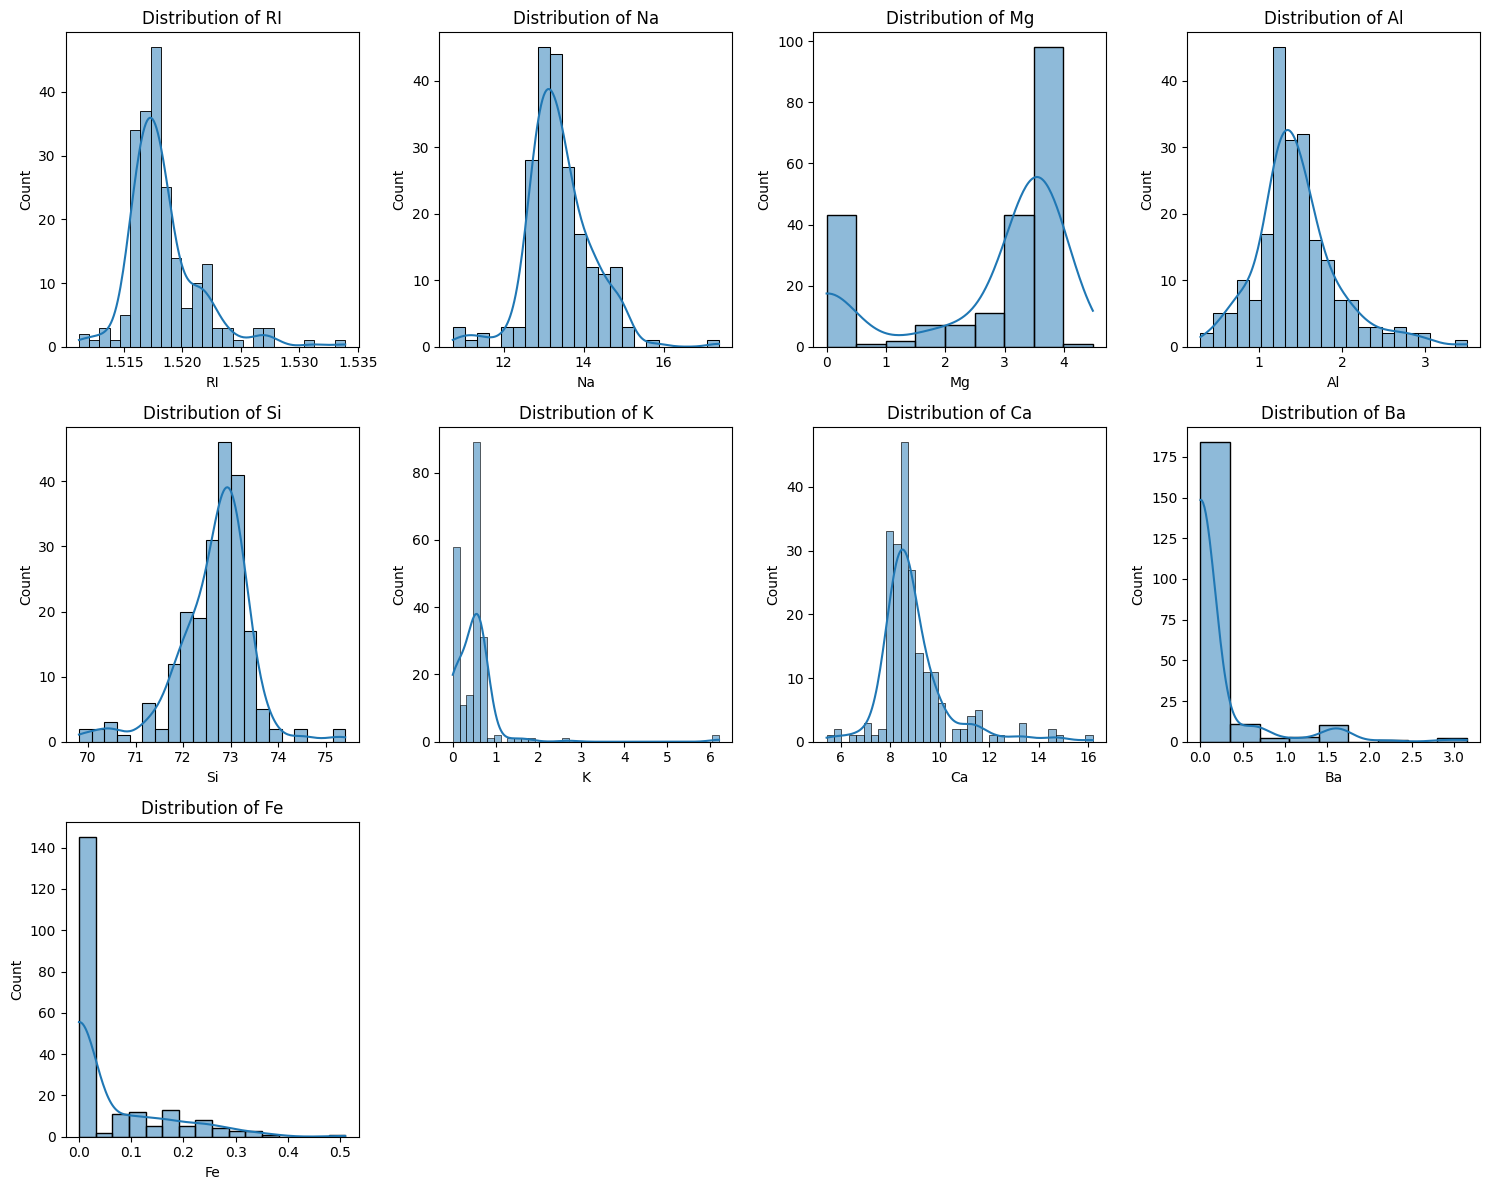

In [30]:
features = data.columns[:-1]

# Plot histograms for each feature
plt.figure(figsize=(15, 12))
for i, col in enumerate(features):
    plt.subplot(3, 4, i + 1)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

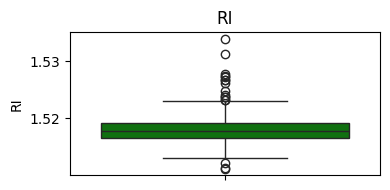

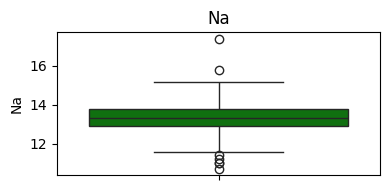

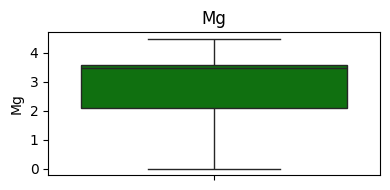

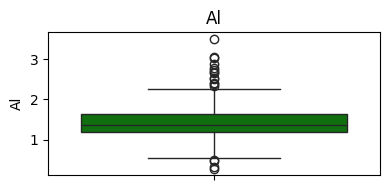

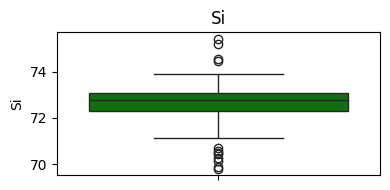

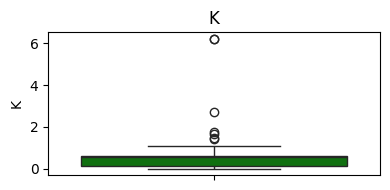

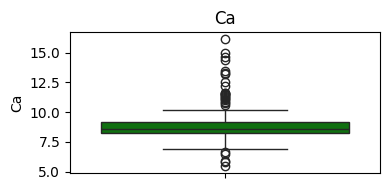

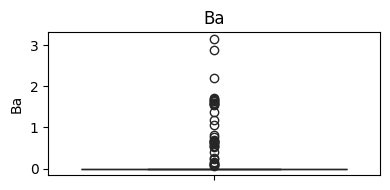

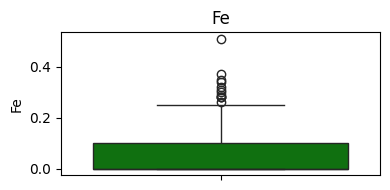

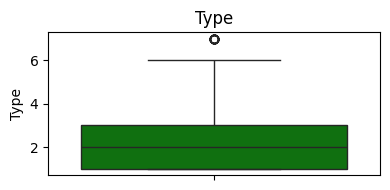

In [14]:
for col in data.columns:
  plt.figure(figsize=(4,2))
  plt.title(col)
  sns.boxplot(data[col],color='Green')
  plt.tight_layout()
  plt.show()

In [15]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
print(IQR)

RI      0.00263
Na      0.91000
Mg      1.51000
Al      0.44000
Si      0.81000
K       0.48000
Ca      0.91000
Ba      0.00000
Fe      0.10000
Type    2.00000
dtype: float64


In [16]:
data.nunique()

,0
RI,178
Na,142
Mg,94
Al,118
Si,133
K,65
Ca,143
Ba,34
Fe,32
Type,6


In [17]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Keep rows where ALL numeric columns are within bounds
data_iqr = data[~((data < lower_bound) | (data > upper_bound)).any(axis=1)]


In [18]:
data_iqr.shape

(135, 10)

<Axes: >

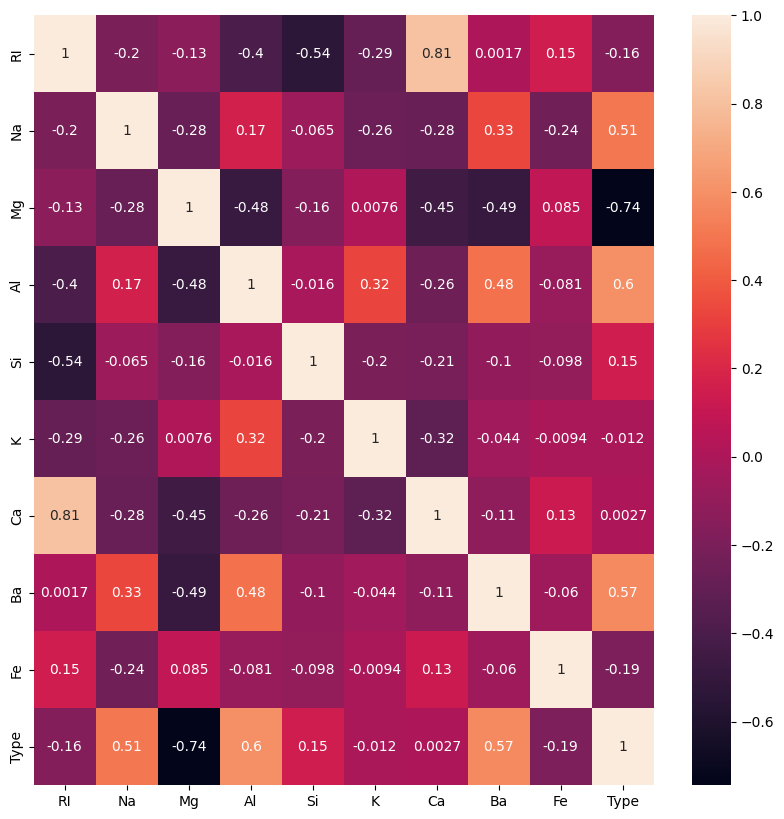

In [19]:
#correlation
plt.figure(figsize=(10,10))
sns.heatmap(data.corr(),annot=True)
#

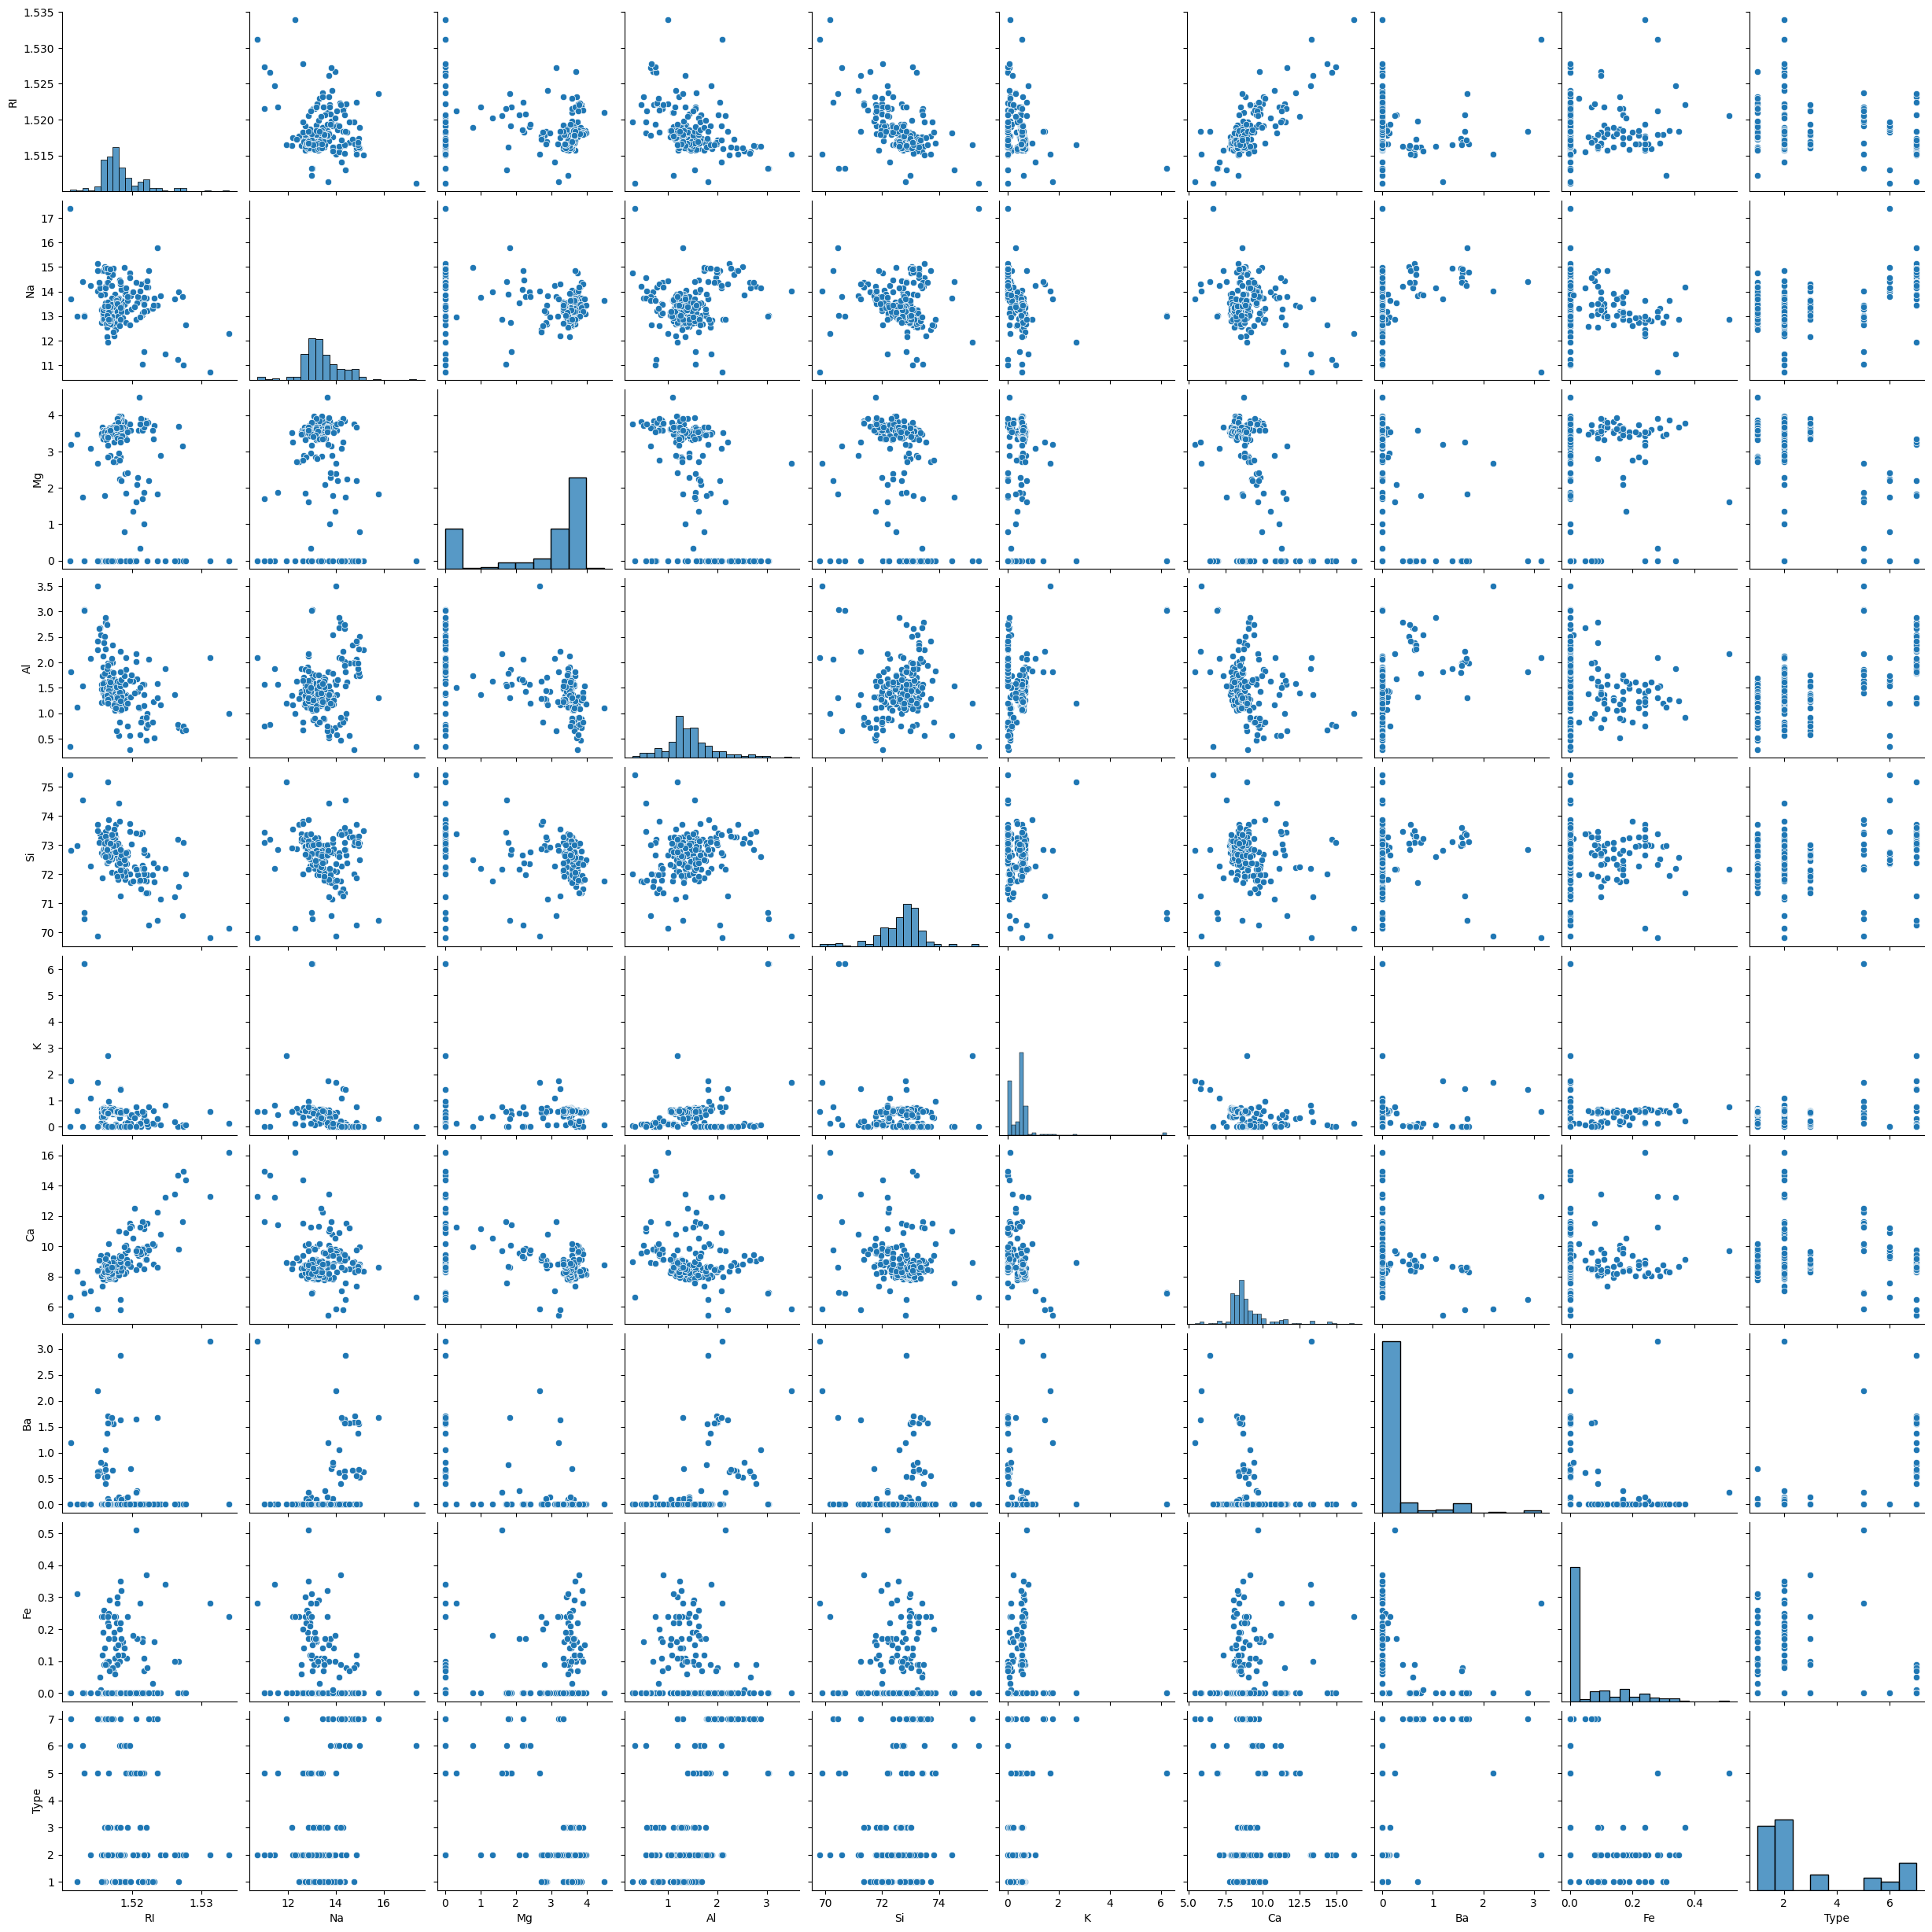

In [20]:
sns.pairplot(data)

In [46]:
#random forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [47]:
X = data.drop('Type', axis=1)
y = data['Type']

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)


In [48]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [49]:
classifier = RandomForestClassifier(n_estimators=100,class_weight='balanced', random_state=42)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

In [50]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.813953488372093


<Axes: >

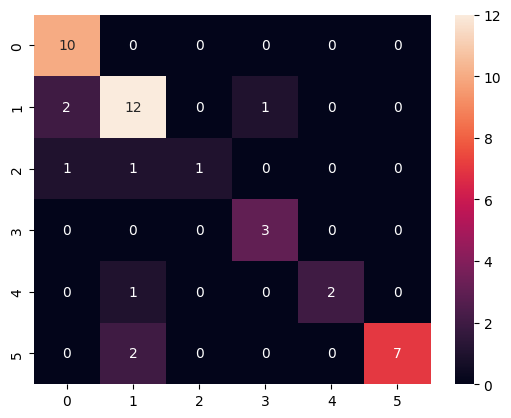

In [51]:
conf_matrx = confusion_matrix(y_test,y_pred)
sns.heatmap(conf_matrx, annot = True)


In [52]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           1       0.77      1.00      0.87        10
           2       0.75      0.80      0.77        15
           3       1.00      0.33      0.50         3
           5       0.75      1.00      0.86         3
           6       1.00      0.67      0.80         3
           7       1.00      0.78      0.88         9

    accuracy                           0.81        43
   macro avg       0.88      0.76      0.78        43
weighted avg       0.84      0.81      0.81        43



In [53]:
#xgboost
from xgboost import XGBClassifier


In [54]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xg_classifier = XGBClassifier()
xg_classifier.fit(X_train, y_train_encoded)
y_pred_encoded = xg_classifier.predict(X_test)

y_pred = le.inverse_transform(y_pred_encoded)


In [55]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8604651162790697


<Axes: >

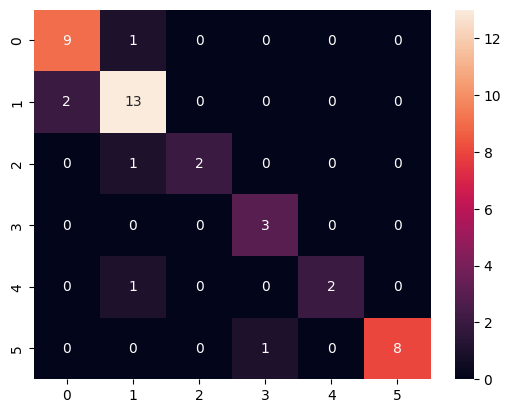

In [56]:
conf_matrx = confusion_matrix(y_test,y_pred)
sns.heatmap(conf_matrx, annot = True)

In [57]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           1       0.82      0.90      0.86        10
           2       0.81      0.87      0.84        15
           3       1.00      0.67      0.80         3
           5       0.75      1.00      0.86         3
           6       1.00      0.67      0.80         3
           7       1.00      0.89      0.94         9

    accuracy                           0.86        43
   macro avg       0.90      0.83      0.85        43
weighted avg       0.87      0.86      0.86        43



After applying XGboost the model has shown greater accuracy of 86%, Which is jump of ~10% from random Forest.

For treating imbalanced dataset we use class_weight='balanced' in randomforest.

## Explain Bagging and Boosting

**Bagging (Bootstrap Aggregating):**
- **Concept:** Bagging is an ensemble learning method that aims to improve the stability and accuracy of machine learning algorithms. It works by training multiple models (typically of the same type, e.g., decision trees) on different subsets of the training data, where each subset is created by sampling with replacement (bootstrapping).
- **How it works:**
  1. **Bootstrapping:** Create `n` new training datasets, each by randomly sampling the original dataset with replacement. Each new dataset will have the same size as the original, but some instances may be repeated, and some may be left out.
  2. **Model Training:** Train a separate base model (e.g., decision tree) on each of these `n` bootstrap samples.
  3. **Aggregation:** For regression tasks, the predictions of the `n` models are averaged. For classification tasks, the predictions are combined via majority voting.
- **Benefits:** Reduces variance, improves generalization, and helps to avoid overfitting. Random Forest is a popular example of a bagging algorithm.

**Boosting:**
- **Concept:** Boosting is another ensemble learning technique that focuses on improving predictive accuracy by sequentially training models. Unlike bagging, where models are trained independently, boosting builds models iteratively, with each new model attempting to correct the errors of the previous ones.
- **How it works:**
  1. **Initial Model:** An initial base model (often a weak learner, like a shallow decision tree) is trained on the entire dataset.
  2. **Weighted Data:** Subsequent models are trained on the same dataset, but the weights of misclassified instances (in the case of classification) or instances with high errors (in the case of regression) are increased. This forces the new model to focus more on the

## Explain Imbalanced Data Handling

**Imbalanced Datasets:**
An imbalanced dataset is one where the number of observations belonging to one class is significantly lower than those belonging to other classes. This is a common problem in many real-world machine learning tasks, such as fraud detection, rare disease diagnosis, or anomaly detection. When a dataset is imbalanced, standard classification algorithms tend to be biased towards the majority class, leading to poor predictive performance on the minority class.

**Why it's a Problem:**
- **Bias towards Majority Class:** Algorithms optimize for overall accuracy, which can be misleading. A model might achieve high accuracy by simply predicting the majority class for all instances, while completely failing to identify the minority class.
- **Poor Generalization:** The model might not learn the underlying patterns of the minority class effectively, leading to poor generalization on unseen data.
- **Misleading Evaluation Metrics:** Metrics like accuracy can be deceptive. Precision, recall, and F1-score are more appropriate for evaluating models on imbalanced datasets.

**Common Techniques for Handling Imbalanced Data:**

1.  **Resampling Techniques:**
    *   **Oversampling Minority Class:**
        *   **Random Oversampling:** Duplicates random instances from the minority class to increase its representation. (Simplest method)
        *   **SMOTE (Synthetic Minority Over-sampling Technique):** Creates synthetic samples for the minority class. It works by taking a sample from the minority class, finding its k-nearest neighbors, and then creating new synthetic samples along the line segments joining the sample to its neighbors.
        *   **ADASYN (Adaptive Synthetic Sampling):** Similar to SMOTE but focuses on generating synthetic samples for minority class instances that are harder to learn.
    *   **Undersampling Majority Class:**
        *   **Random Undersampling:** Randomly removes instances from the majority class. (Can lead to loss of valuable information).
        *   **Tomek Links:** Identifies pairs of instances of different classes that are close to each other, where the majority class instance is removed.
        *   **ENN (Edited Nearest Neighbors):** Removes majority class instances whose k-nearest neighbors are mostly from other classes.

2.  **Algorithm-Level Approaches:**
    *   **Cost-Sensitive Learning:** Modifies the learning algorithm to penalize misclassifications of the minority class more heavily than misclassifications of the majority class. This can be done by assigning different misclassification costs.
    *   **Tree-based Algorithms with `class_weight`:** Many tree-based algorithms (like Decision Trees, Random Forests, Gradient Boosting) have a `class_weight` parameter that can be set to `'balanced'` or custom weights. This automatically adjusts weights inversely proportional to class frequencies, giving more importance to the minority class.
    *   **Ensemble Methods:** Bagging and Boosting algorithms can sometimes perform well on imbalanced datasets, especially when combined with resampling techniques or cost-sensitive learning.

3.  **Evaluation Metrics:**
    -   Instead of just accuracy, focus on:
        *   **Precision:** The proportion of correctly predicted positive observations among all predicted positive observations.
        *   **Recall (Sensitivity):** The proportion of correctly predicted positive observations among all actual positive observations.
        *   **F1-Score:** The harmonic mean of Precision and Recall, providing a balance between the two.
        *   **Confusion Matrix:** Provides a detailed breakdown of correct and incorrect classifications for each class.
        *   **ROC AUC (Receiver Operating Characteristic - Area Under the Curve):** Measures the ability of a classifier to distinguish between classes. A higher AUC indicates better model performance.

4.  **Other Strategies:**
    *   **Generate More Data:** If possible, collect more data for the minority class.
    *   **Feature Engineering:** Create new features that help the model better distinguish between classes.

In the context of the Random Forest model we used, `class_weight='balanced'` is an effective strategy to address class imbalance at the algorithm level.